# 바질 병해 진단

ResNet18 2단계: 정상 vs 이상 → 3-class(정상/병원성/환경·생리) 진단. Private 잎 crop 포함.


In [1]:
# 설정
from pathlib import Path
import hashlib
import random
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FARMETRY_DIR = ROOT
BASE_DIR = FARMETRY_DIR / "data" / "samples" / "basil_disease"
PRIVATE_IMG_DIR = FARMETRY_DIR / "Farmetry_Data" / "0623_firebase"  # 원본(비공개)
PRIVATE_CROP_DIR = FARMETRY_DIR / "data" / "private_healthy_crops"
MODEL_DIR = FARMETRY_DIR / "models"
STAGE1_PATH = MODEL_DIR / "basil_stage1_binary.pth"
IMG_EXT = {".jpg", ".jpeg", ".png", ".webp", ".jfif", ".bmp", ".gif"}

# 학습에서 제외할 클래스
EXCLUDED_CLASSES = {"Pest_Damage", "Sun_Scald_Burn"}

# 폴더명 → 한글 클래스명 (6 — class)
CLASS_KO = {
    "Healthy": "정상",
    "Downy_Mildew": "노균병",
    "Fusarium_Wilt": "바실라리움 시들음병",
    "Leaf_Spot_Fungal": "잎반점(곰팡이)",
    "Nutrient_Deficienc": "영양 결핍",
    "Overwatering_Rot": "과습/뿌리썩음",
}
CLASS_NAMES = list(CLASS_KO.keys())
CLASS_LABELS = list(CLASS_KO.values())

# 6 — class → 3 super — class (정상 / 병원성 / 환경·생리)
CLASS_TO_SUPER = {
    "Healthy": "Healthy",
    "Downy_Mildew": "Pathogenic",
    "Fusarium_Wilt": "Pathogenic",
    "Leaf_Spot_Fungal": "Pathogenic",
    "Nutrient_Deficienc": "Abiotic",
    "Overwatering_Rot": "Abiotic",
}
SUPER_KO = {"Healthy": "정상", "Pathogenic": "병원성", "Abiotic": "환경·생리"}
SUPER_NAMES = list(SUPER_KO.keys())

PRIVATE_TRAIN_RATIO = 2 / 3  # private crop 중 학습 비율
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

print("BASE_DIR:", BASE_DIR, "| exists:", BASE_DIR.exists())
print("PRIVATE_IMG_DIR:", PRIVATE_IMG_DIR, "| exists:", PRIVATE_IMG_DIR.exists())
print("제외 클래스:", sorted(EXCLUDED_CLASSES))
print("사용 클래스:", CLASS_NAMES)


BASE_DIR: C:\Users\msyu7\Desktop\HYU\Farmetry\Dataset_disease\Basil_disease\Basil_Diseases | exists: True
PRIVATE_IMG_DIR: C:\Users\msyu7\Desktop\HYU\Farmetry\Farmetry_Data\0623_firebase | exists: True
제외 클래스: ['Pest_Damage', 'Sun_Scald_Burn']
사용 클래스: ['Healthy', 'Downy_Mildew', 'Fusarium_Wilt', 'Leaf_Spot_Fungal', 'Nutrient_Deficienc', 'Overwatering_Rot']


In [2]:
# 데이터 로드
rows = []
skipped = 0
for cls_dir in sorted(BASE_DIR.iterdir()):
    if not cls_dir.is_dir():
        continue
    cls = cls_dir.name
    if cls in EXCLUDED_CLASSES:
        skipped += sum(1 for p in cls_dir.rglob("*") if p.suffix.lower() in IMG_EXT)
        continue
    for p in cls_dir.rglob("*"):
        if p.suffix.lower() not in IMG_EXT:
            continue
        try:
            with Image.open(p) as im:
                w, h = im.size
                mode, fmt = im.mode, im.format
        except Exception:
            w = h = mode = fmt = None
        md5 = hashlib.md5(p.read_bytes()).hexdigest()
        rows.append({
            "class": cls,
            "class_ko": CLASS_KO.get(cls, cls),
            "image_name": p.name,
            "ext": p.suffix.lower(),
            "image_path": p,
            "width": w,
            "height": h,
            "aspect": round(w / h, 3) if w and h else None,
            "size_kb": round(p.stat().st_size / 1024, 1),
            "mode": mode,
            "format": fmt,
            "md5": md5,
            "source": "basil",
        })

df_basil = pd.DataFrame(rows)
print(f"Basil 사용 {len(df_basil)}장 | 제외 {skipped}장 | 클래스 {df_basil['class'].nunique()}개")
print(df_basil["class_ko"].value_counts().to_string())
df_basil.head(3)


Basil 사용 628장 | 제외 210장 | 클래스 6개
class_ko
잎반점(곰팡이)      110
바실라리움 시들음병    107
영양 결핍         107
노균병           106
정상            105
과습/뿌리썩음        93


,class,class_ko,image_name,ext,image_path,width,height,aspect,size_kb,mode,format,md5,source
0,Downy_Mildew,노균병,1.jpg,.jpg,C:\Users\msyu7\Desktop\HYU\Farmetry\Dataset_di...,325,155,2.097,6.8,RGB,JPEG,dce6ce66f5609cee83a6154a7882d731,basil
1,Downy_Mildew,노균병,11.jpg,.jpg,C:\Users\msyu7\Desktop\HYU\Farmetry\Dataset_di...,87,109,0.798,4.4,RGB,JPEG,a13e80031c4cb7ee865796f328615b6e,basil
2,Downy_Mildew,노균병,4-dogwood_pm.jpg,.jpg,C:\Users\msyu7\Desktop\HYU\Farmetry\Dataset_di...,600,400,1.500,42.5,RGB,JPEG,ce0850c20b5cf84470cae08cf7530d8d,basil


1. 클래스 분포 (파일 수)
class_ko
잎반점(곰팡이)      110
바실라리움 시들음병    107
영양 결핍         107
노균병           106
정상            105
과습/뿌리썩음        93

2. 이미지 포맷: {'.jpg': 616, '.webp': 9, '.jfif': 2, '.png': 1}
3. 해상도: width 43~6000 | height 68~4080
4. 파일 크기(KB): min 2.7 | median 9.6 | max 3503.4

5. 고유 이미지(내용 기준): 282장 / 전체 628장 → 중복 복사 346건


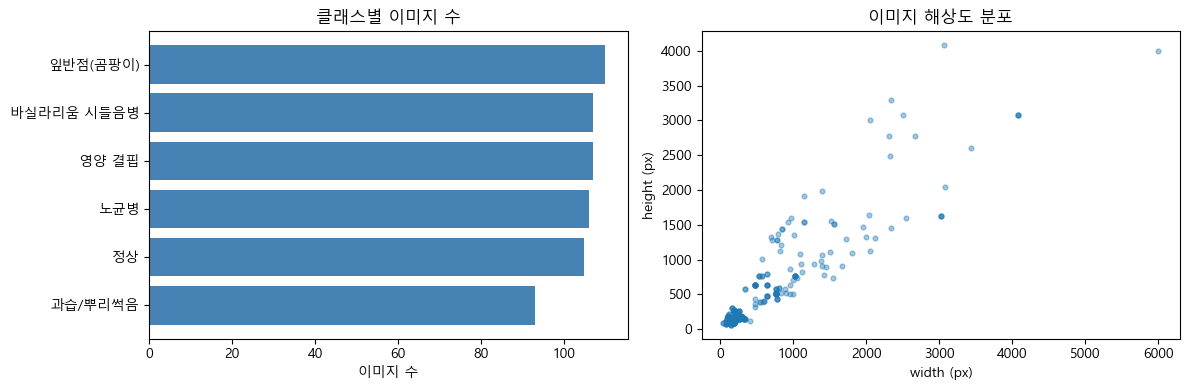

In [3]:
# EDA
print("=" * 50)
print("1. 클래스 분포 (파일 수)")
print(df_basil["class_ko"].value_counts().to_string())
print(f"\n2. 이미지 포맷: {df_basil['ext'].value_counts().to_dict()}")
print(f"3. 해상도: width {df_basil['width'].min()}~{df_basil['width'].max()} | height {df_basil['height'].min()}~{df_basil['height'].max()}")
print(f"4. 파일 크기(KB): min {df_basil['size_kb'].min()} | median {df_basil['size_kb'].median():.1f} | max {df_basil['size_kb'].max()}")

# 고유 이미지 vs 중복
n_unique = df_basil["md5"].nunique()
n_dup_files = len(df_basil) - n_unique
print(f"\n5. 고유 이미지(내용 기준): {n_unique}장 / 전체 {len(df_basil)}장 → 중복 복사 {n_dup_files}건")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 클래스 분포 bar
counts = df_basil["class_ko"].value_counts()
axes[0].barh(counts.index, counts.values, color="steelblue")
axes[0].set_xlabel("이미지 수")
axes[0].set_title("클래스별 이미지 수")
axes[0].invert_yaxis()

# 해상도 scatter (샘플링)
sample = df_basil.dropna(subset=["width", "height"]).sample(min(400, len(df_basil)), random_state=SEED)
axes[1].scatter(sample["width"], sample["height"], alpha=0.4, s=12)
axes[1].set_xlabel("width (px)")
axes[1].set_ylabel("height (px)")
axes[1].set_title("이미지 해상도 분포")
plt.tight_layout()
plt.show()

서로 다른 클래스에 동일 이미지가 들어간 경우: 171건
(학습 전 dedup 또는 train/val split 시 md5 기준 분리 권장)

  class_ko  파일수  클래스 고유  다른 클래스와 공유
       노균병  106       0         106
바실라리움 시들음병  107       3         104
        정상  105     105           0
  잎반점(곰팡이)  110       6         104
     영양 결핍  107       1         106
   과습/뿌리썩음   93       0          93


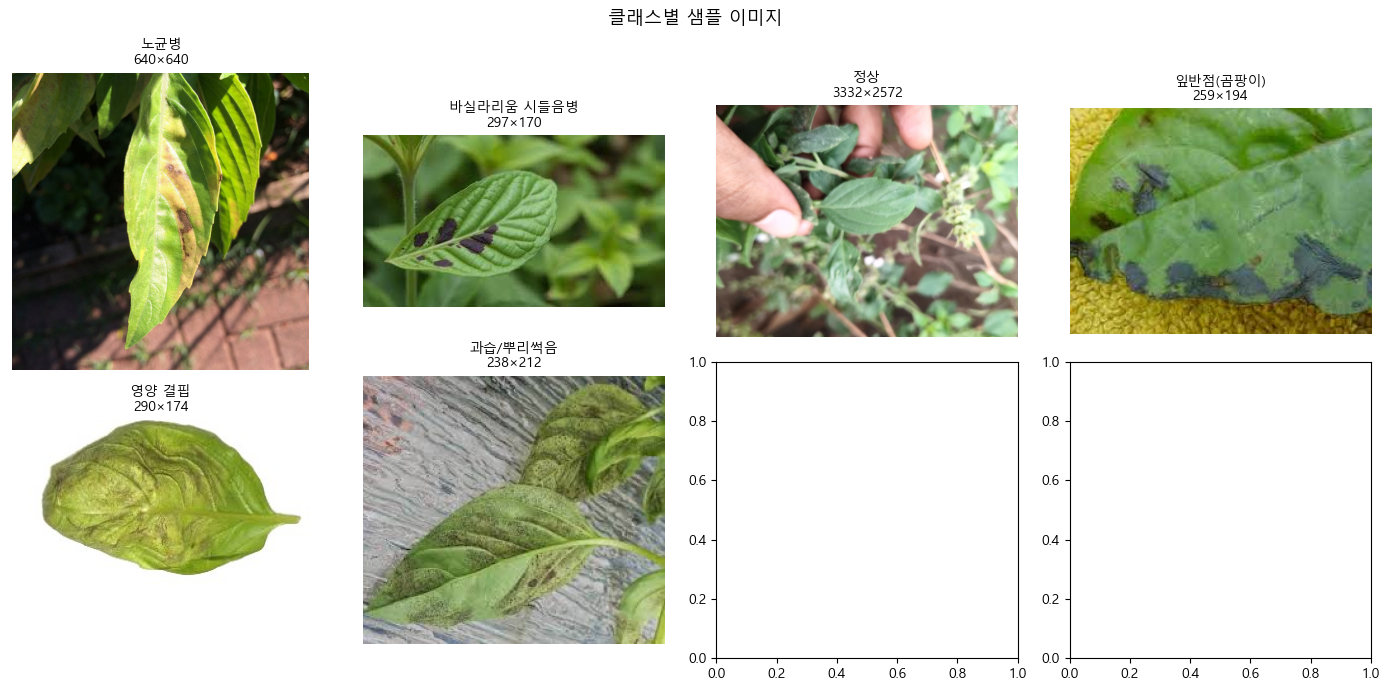

In [4]:
# 중복 분석 및 샘플
from collections import defaultdict

hash_to_classes = df_basil.groupby("md5")["class"].apply(lambda s: sorted(set(s))).to_dict()
cross_class = {h: cls for h, cls in hash_to_classes.items() if len(cls) > 1}

print(f"서로 다른 클래스에 동일 이미지가 들어간 경우: {len(cross_class)}건")
print("(학습 전 dedup 또는 train/val split 시 md5 기준 분리 권장)\n")

# 클래스별 고유/공유 이미지 수
unique_stats = []
for cls in sorted(df_basil["class"].unique()):
    sub = df_basil[df_basil["class"] == cls]
    only_here = sum(1 for h in sub["md5"] if hash_to_classes[h] == [cls])
    shared = len(sub) - only_here
    unique_stats.append({"class_ko": CLASS_KO[cls], "파일수": len(sub), "클래스 고유": only_here, "다른 클래스와 공유": shared})
stats_df = pd.DataFrame(unique_stats)
print(stats_df.to_string(index=False))

# 클래스별 샘플 1장씩
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, cls in zip(axes.ravel(), sorted(df_basil["class"].unique())):
    row = df_basil[df_basil["class"] == cls].sample(1, random_state=SEED).iloc[0]
    img = Image.open(row["image_path"]).convert("RGB")
    ax.imshow(img)
    ax.set_title(f"{CLASS_KO[cls]}\n{row['width']}×{row['height']}", fontsize=10)
    ax.axis("off")
plt.suptitle("클래스별 샘플 이미지", fontsize=13)
plt.tight_layout()
plt.show()

In [5]:
# 라벨 설정
df_basil["super_class"] = df_basil["class"].map(CLASS_TO_SUPER)
df_basil["super_ko"] = df_basil["super_class"].map(SUPER_KO)
SUPER_LABELS = [SUPER_KO[s] for s in SUPER_NAMES]

df_basil["label6"] = df_basil["class"].map({c: i for i, c in enumerate(CLASS_NAMES)})
df_basil["label3"] = df_basil["super_class"].map({s: i for i, s in enumerate(SUPER_NAMES)})
df_basil["label2"] = (df_basil["super_class"] != "Healthy").astype(int)
BINARY_NAMES = ["Healthy", "Abnormal"]

print(f"Basil {len(df_basil)}장")
print("\n3 super-class:")
print(df_basil["super_ko"].value_counts().to_string())
print("\n6-class:")
print(df_basil["class_ko"].value_counts().to_string())


Basil 628장

3 super-class:
super_ko
병원성      323
환경·생리    200
정상       105

6-class:
class_ko
잎반점(곰팡이)      110
바실라리움 시들음병    107
영양 결핍         107
노균병           106
정상            105
과습/뿌리썩음        93


녹색 면적 crop | 원본 28장 | MIN_AREA=150 (task1 동일)
처리 시간: 16.7s
  원본 split: 학습 18장 / 평가 10장
Private 원본 28장 → crop 743개
  학습 444 | 평가 전용 299

최종 학습 풀 df_train: 1072 (basil 628 + private 444)
     parent_image  crop_id  area_px
0  1782114891.jpg        0     2863
1  1782114891.jpg        1     3209
2  1782114891.jpg        2      176
3  1782114891.jpg        3     2271
4  1782114891.jpg        4     1510

[crop 예시 8장] task1과 동일 로직 — crop 적으면 MIN_AREA 조절


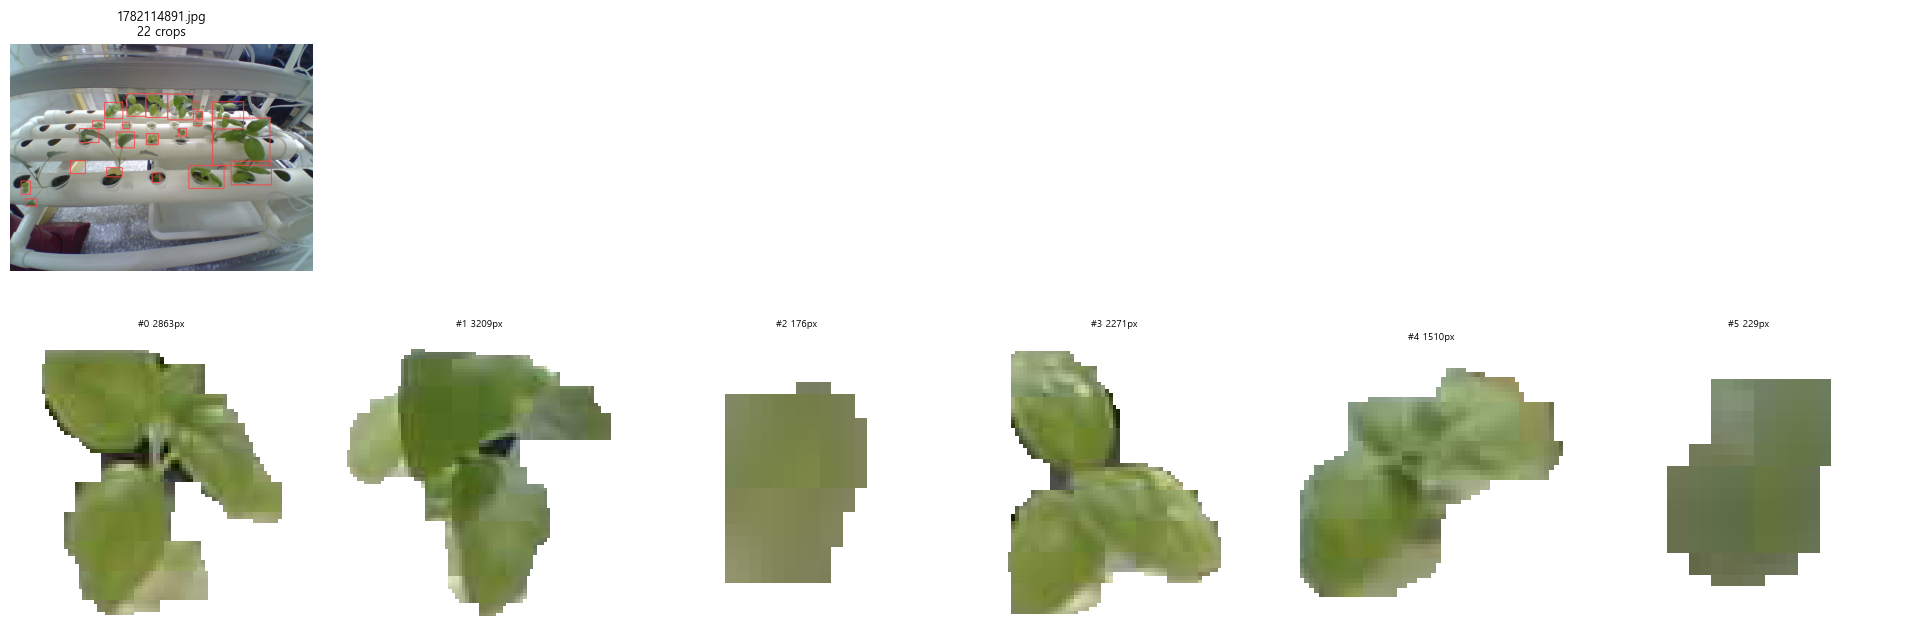

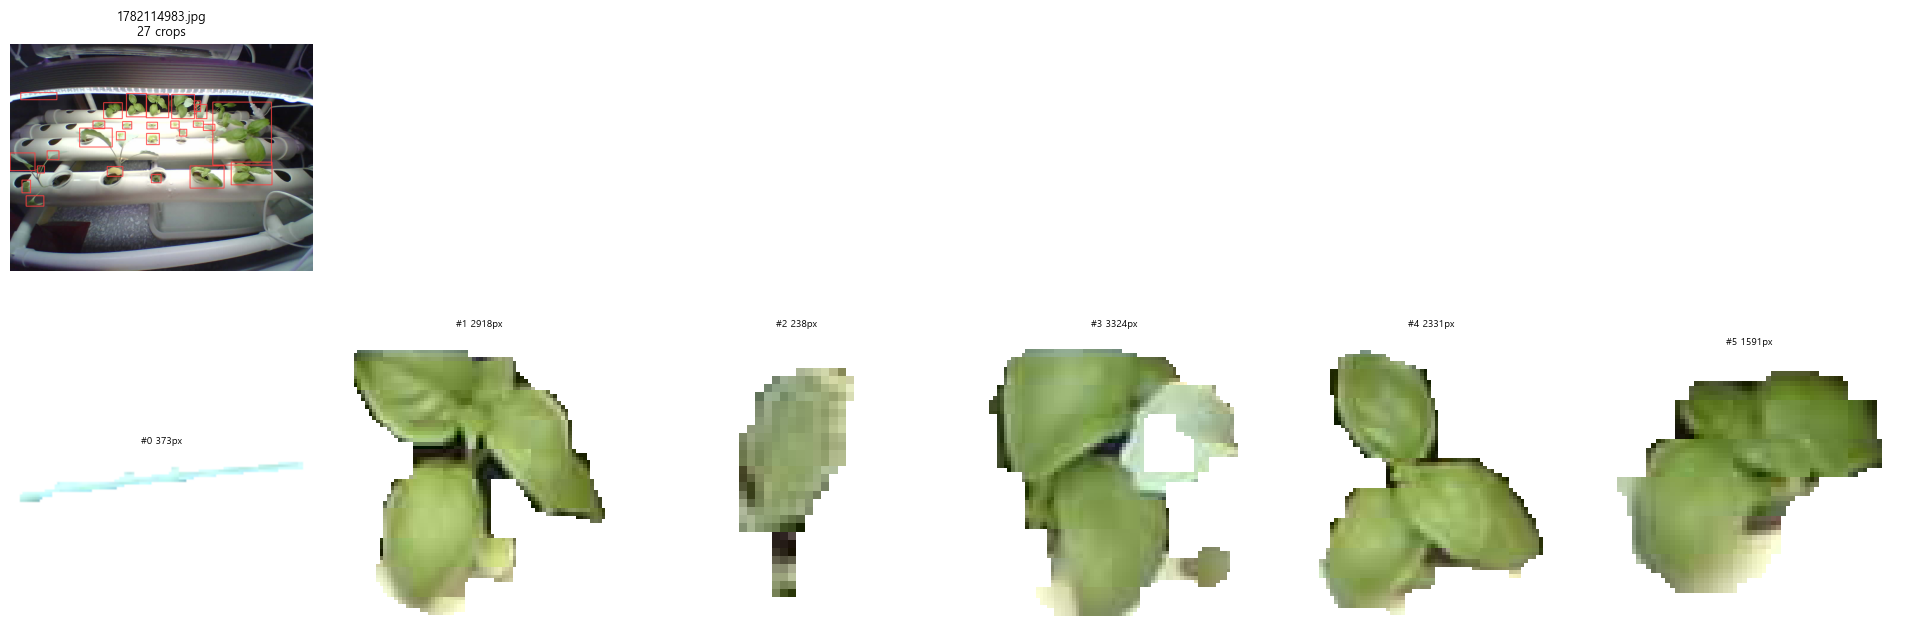

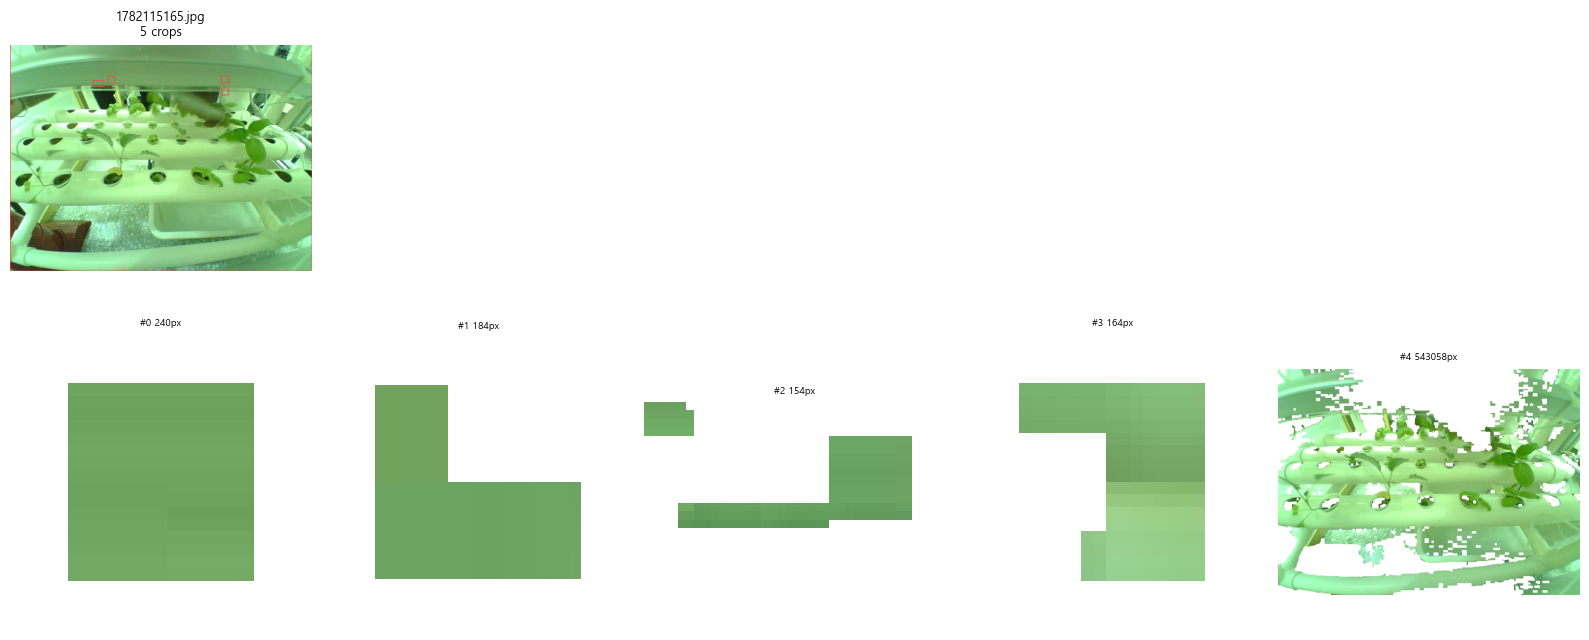

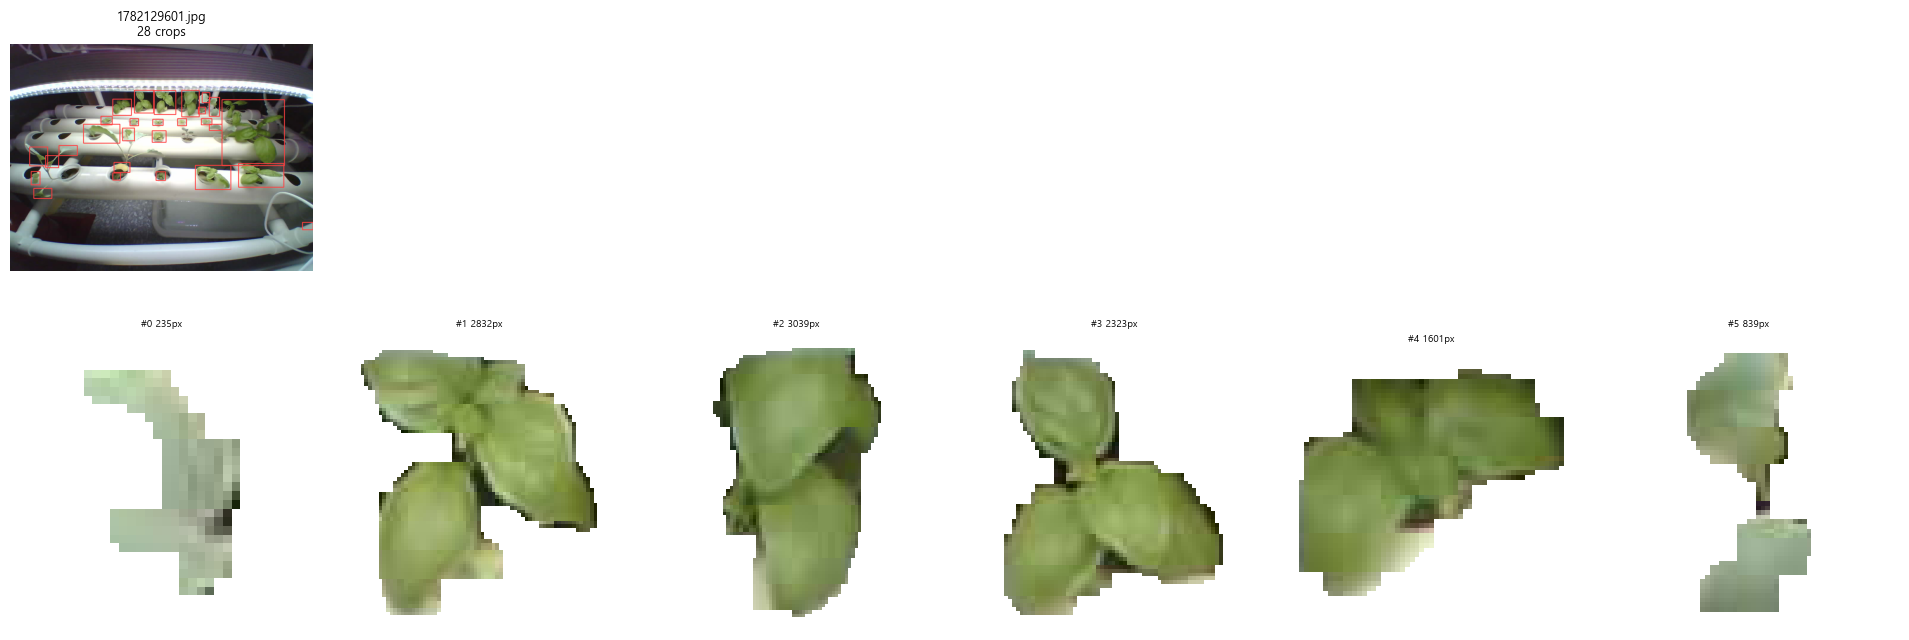

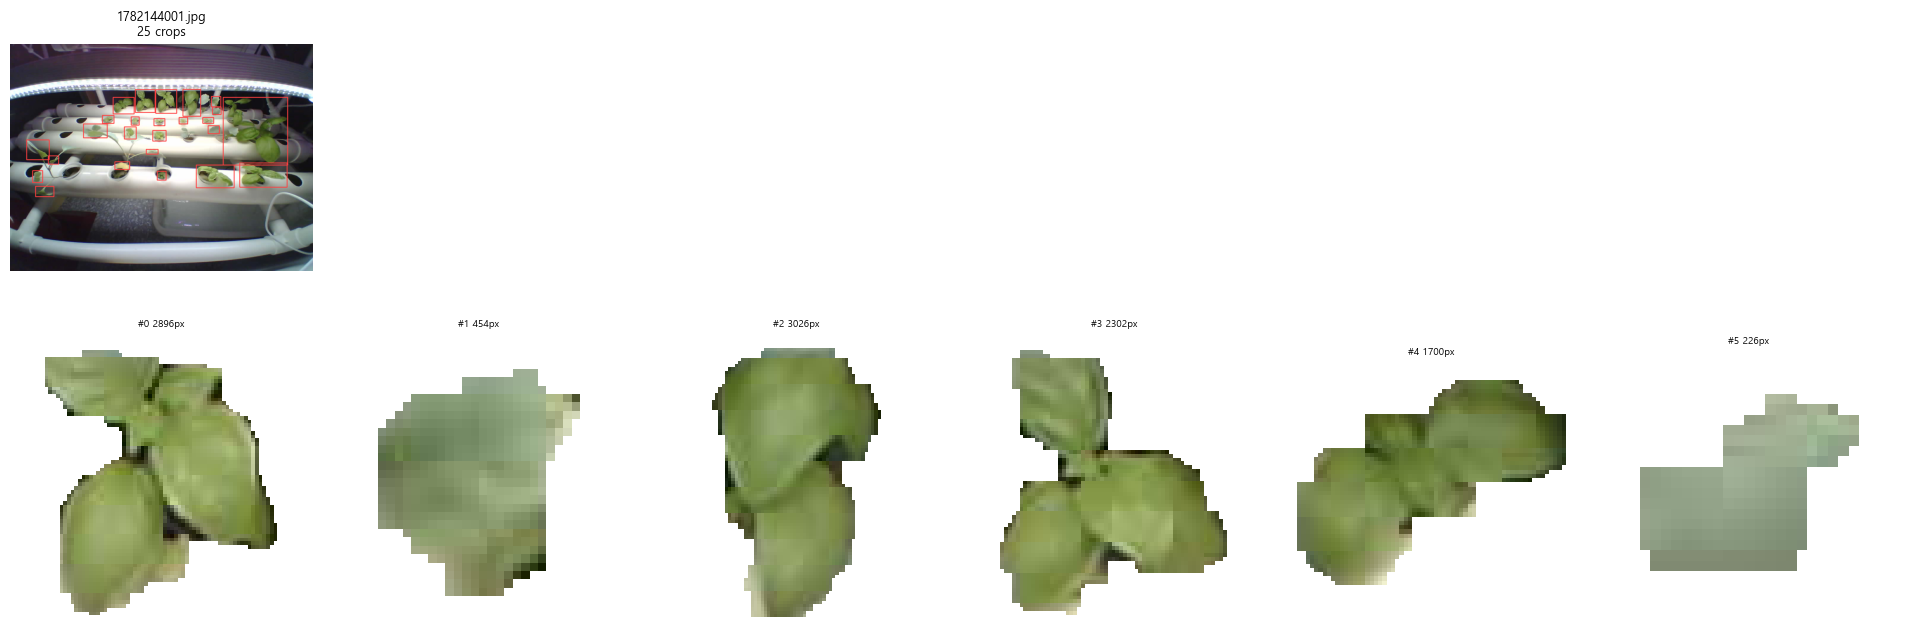

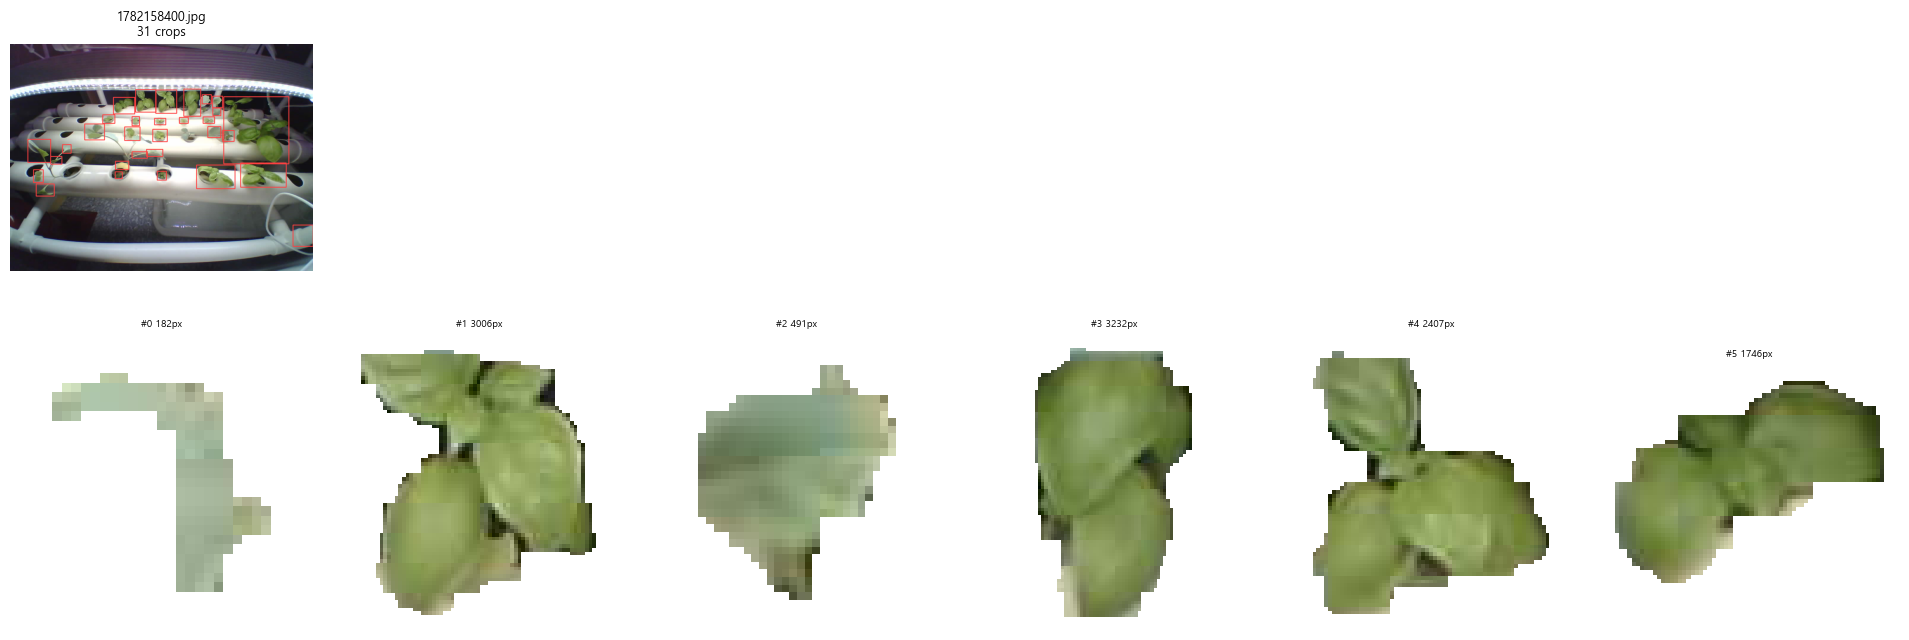

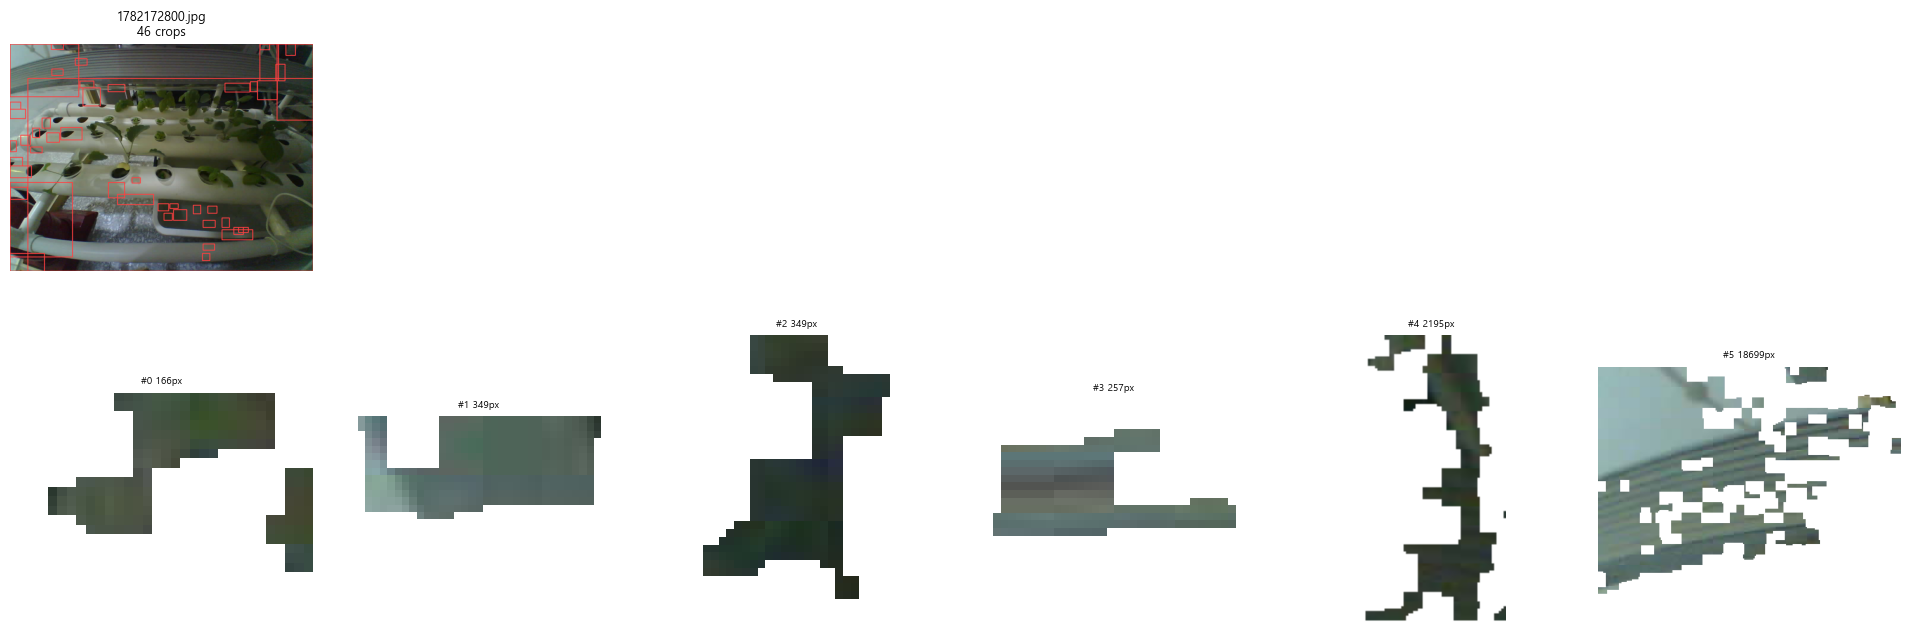

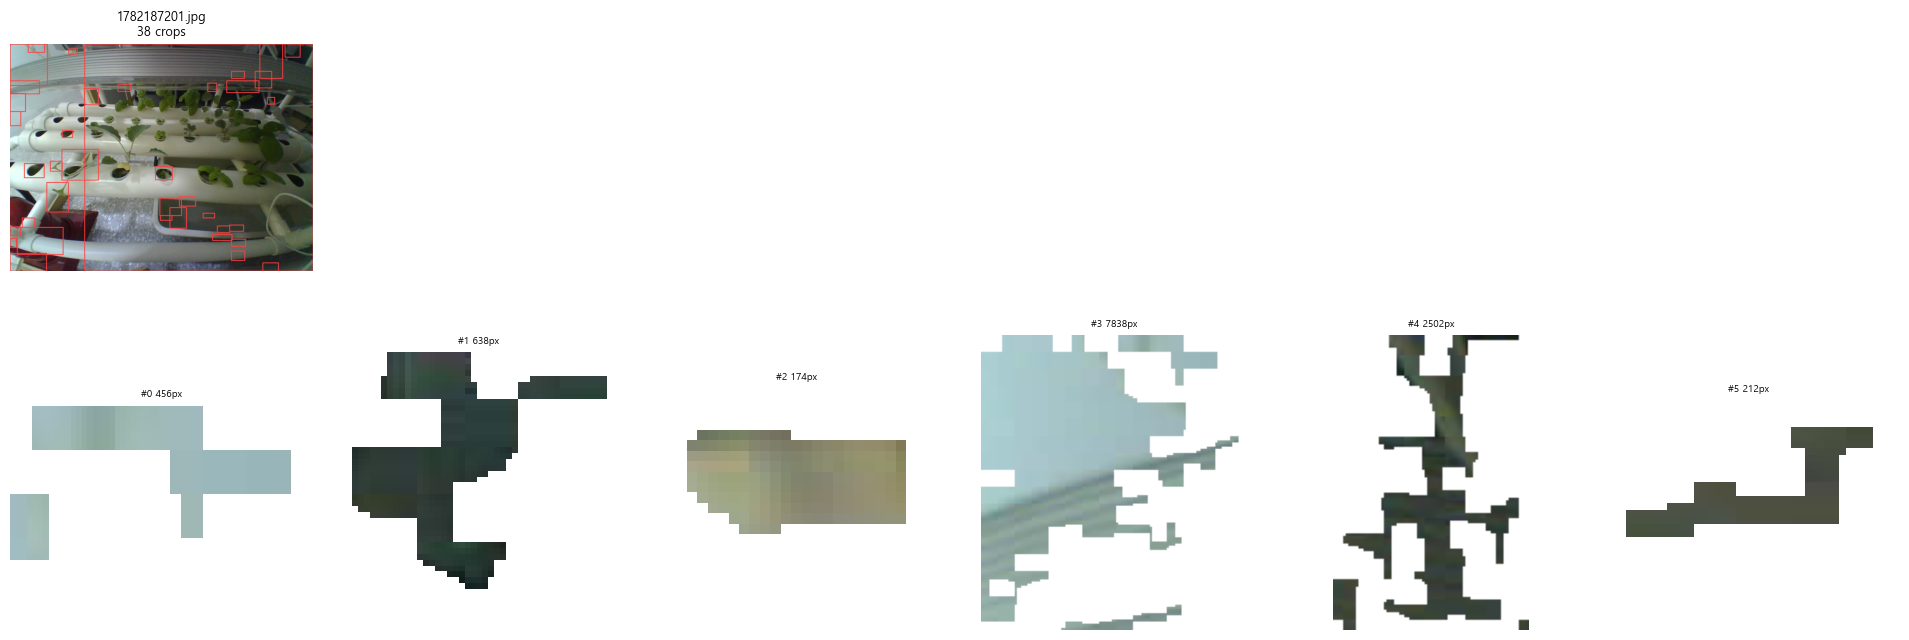

In [6]:
# Private 잎 crop
import cv2
import shutil
import time
from sklearn.model_selection import train_test_split

MIN_AREA = 150  # task1_0522와 동일
PAD = 4
MASK_BG_BGR = (255, 255, 255)
PREVIEW_MAX_IMAGES = 8


def imread_bgr(path):
    data = np.fromfile(str(path), dtype=np.uint8)
    if data.size == 0:
        return None
    return cv2.imdecode(data, cv2.IMREAD_COLOR)


def build_mask(img_bgr):
    """task1_0522와 동일: HSV + ExG + morphology."""
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

    lower_green = np.array([25, 35, 25])
    upper_green = np.array([95, 255, 255])
    mask_hsv = cv2.inRange(hsv, lower_green, upper_green)

    b, g, r = cv2.split(img_bgr.astype(np.float32))
    exg = 2 * g - r - b
    exg_norm = cv2.normalize(exg, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    _, mask_exg = cv2.threshold(exg_norm, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    mask = cv2.bitwise_and(mask_hsv, mask_exg)

    kernel_open = np.ones((3, 3), np.uint8)
    kernel_close = np.ones((7, 7), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel_open)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel_close)
    return mask


def analyze_components(mask, min_area=MIN_AREA):
    """task1_0522와 동일: connectedComponents + min_area 필터."""
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask, 8)

    clean_mask = np.zeros(mask.shape, dtype=np.uint8)
    rows = []
    plant_no = 1

    for i in range(1, num_labels):
        area_px = int(stats[i, cv2.CC_STAT_AREA])
        if area_px < min_area:
            continue

        x = int(stats[i, cv2.CC_STAT_LEFT])
        y = int(stats[i, cv2.CC_STAT_TOP])
        w = int(stats[i, cv2.CC_STAT_WIDTH])
        h = int(stats[i, cv2.CC_STAT_HEIGHT])
        cx = float(centroids[i][0])
        cy = float(centroids[i][1])

        clean_mask[labels == i] = 255
        rows.append({
            "plant_id": plant_no,
            "area_px": area_px,
            "x": x, "y": y, "w": w, "h": h,
            "cx": cx, "cy": cy,
        })
        plant_no += 1

    rows.sort(key=lambda row: (row["cy"], row["cx"]))
    for j, row in enumerate(rows):
        row["crop_id"] = j
    return clean_mask, rows


def extract_leaf_boxes(img_bgr, min_area=MIN_AREA):
    h_img, w_img = img_bgr.shape[:2]
    mask = build_mask(img_bgr)
    clean_mask, rows = analyze_components(mask, min_area=min_area)

    boxes = []
    for row in rows:
        x, y, w, h = row["x"], row["y"], row["w"], row["h"]
        boxes.append({
            "x0": max(0, x - PAD), "y0": max(0, y - PAD),
            "x1": min(w_img, x + w + PAD), "y1": min(h_img, y + h + PAD),
            "area_px": row["area_px"],
            "crop_id": row["crop_id"],
        })
    return boxes, clean_mask


def make_crop(img_bgr, box, clean_mask):
    sl = img_bgr[box["y0"]:box["y1"], box["x0"]:box["x1"]].copy()
    m = clean_mask[box["y0"]:box["y1"], box["x0"]:box["x1"]] > 0
    sl[~m] = MASK_BG_BGR
    return sl


def preview_private_crop(img_path, max_show=6):
    bgr = imread_bgr(img_path)
    if bgr is None:
        print("read fail:", img_path)
        return
    boxes, clean_mask = extract_leaf_boxes(bgr)
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    overlay = rgb.copy()
    for b in boxes:
        cv2.rectangle(overlay, (b["x0"], b["y0"]), (b["x1"], b["y1"]), (255, 64, 64), 2)

    ncol = max(min(len(boxes), max_show), 1)
    fig, axes = plt.subplots(2, ncol, figsize=(3.2 * ncol, 6.5))
    if ncol == 1:
        axes = np.array([[axes[0]], [axes[1]]])

    axes[0, 0].imshow(overlay)
    axes[0, 0].set_title(f"{Path(img_path).name}\n{len(boxes)} crops", fontsize=9)
    axes[0, 0].axis("off")
    for j in range(1, ncol):
        axes[0, j].axis("off")

    if not boxes:
        axes[1, 0].imshow(clean_mask, cmap="gray")
        axes[1, 0].set_title("binary mask")
        axes[1, 0].axis("off")
    else:
        for j, b in enumerate(boxes[:max_show]):
            crop = make_crop(bgr, b, clean_mask)
            axes[1, j].imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
            axes[1, j].set_title(f"#{b['crop_id']} {b['area_px']}px", fontsize=7)
            axes[1, j].axis("off")
        for j in range(len(boxes[:max_show]), ncol):
            axes[1, j].axis("off")
    plt.tight_layout()
    plt.show()


def preview_crop_gallery(parent_images, n_show=PREVIEW_MAX_IMAGES):
    if not parent_images:
        return
    if len(parent_images) <= n_show:
        picks = list(parent_images)
    else:
        idx = np.linspace(0, len(parent_images) - 1, n_show, dtype=int)
        picks = [parent_images[i] for i in idx]
    print(f"\n[crop 예시 {len(picks)}장] task1과 동일 로직 — crop 적으면 MIN_AREA 조절")
    for p in picks:
        preview_private_crop(p)


def add_private_labels(frame):
    out = frame.copy()
    out["class"] = "Healthy"
    out["class_ko"] = "정상"
    out["super_class"] = "Healthy"
    out["super_ko"] = "정상"
    out["label6"] = CLASS_NAMES.index("Healthy")
    out["label3"] = SUPER_NAMES.index("Healthy")
    out["label2"] = 0
    out["source"] = "private"
    return out


# crop 생성: 원본(비공개)이 있으면 재생성, 없으면 저장소에 포함된 crop 재사용
def _load_existing_private_crops():
    rows = []
    for split in ("train", "eval"):
        d = PRIVATE_CROP_DIR / split
        if not d.exists():
            continue
        for p in sorted(d.glob("*.jpg")):
            stem = p.stem
            if "_leaf" in stem:
                parent, cid = stem.rsplit("_leaf", 1)
                cid = int(cid) if cid.isdigit() else 0
            else:
                parent, cid = stem, 0
            try:
                with Image.open(p) as im:
                    w, h = im.size
            except Exception:
                w = h = None
            rows.append({
                "parent_image": parent, "crop_id": cid,
                "image_name": p.name, "image_path": p,
                "width": w, "height": h, "area_px": np.nan, "bbox": np.nan,
                "md5": hashlib.md5(p.read_bytes()).hexdigest(), "split": split,
            })
    return add_private_labels(pd.DataFrame(rows))

_has_private_src = PRIVATE_IMG_DIR.exists() and any(
    p.suffix.lower() in IMG_EXT for p in PRIVATE_IMG_DIR.iterdir()
)

if not _has_private_src:
    print(f"원본 비공개 이미지 없음 → 포함된 crop 재사용: {PRIVATE_CROP_DIR}")
    df_private_all = _load_existing_private_crops()
    if len(df_private_all) == 0:
        raise RuntimeError(f"private crop 없음: {PRIVATE_CROP_DIR}")
    df_private_train = df_private_all[df_private_all["split"] == "train"].reset_index(drop=True)
    df_private_eval = df_private_all[df_private_all["split"] == "eval"].reset_index(drop=True)
    df_train = pd.concat([df_basil, df_private_train], ignore_index=True)
    print(f"crop 재사용 | 학습 {len(df_private_train)} | 평가 {len(df_private_eval)}")
    print(f"최종 학습 풀 df_train: {len(df_train)} (basil {len(df_basil)} + private {len(df_private_train)})")
else:
    # crop 생성 —  —  — 
    if PRIVATE_CROP_DIR.exists():
        for sub in ("train", "eval", "pending"):
            d = PRIVATE_CROP_DIR / sub
            if d.exists():
                shutil.rmtree(d)
    PRIVATE_CROP_DIR.mkdir(parents=True, exist_ok=True)
    (PRIVATE_CROP_DIR / "train").mkdir(exist_ok=True)
    (PRIVATE_CROP_DIR / "eval").mkdir(exist_ok=True)
    (PRIVATE_CROP_DIR / "pending").mkdir(exist_ok=True)

    private_rows = []
    parent_images = sorted(
        [p for p in PRIVATE_IMG_DIR.iterdir() if p.suffix.lower() in IMG_EXT],
        key=lambda p: p.name,
    )
    print(f"녹색 면적 crop | 원본 {len(parent_images)}장 | MIN_AREA={MIN_AREA} (task1 동일)")
    t_all = time.time()

    for img_path in parent_images:
        bgr = imread_bgr(img_path)
        if bgr is None:
            print(f"  skip (read fail): {img_path.name}")
            continue
        boxes, clean_mask = extract_leaf_boxes(bgr)
        if not boxes:
            print(f"  skip (no leaf): {img_path.name}")
            continue
        for box in boxes:
            cid = box["crop_id"]
            crop = make_crop(bgr, box, clean_mask)
            crop_name = f"{img_path.stem}_leaf{cid}.jpg"
            crop_path = PRIVATE_CROP_DIR / "pending" / crop_name
            cv2.imwrite(str(crop_path), crop)
            ch, cw = crop.shape[:2]
            private_rows.append({
                "parent_image": img_path.name,
                "crop_id": cid,
                "image_name": crop_name,
                "image_path": crop_path,
                "width": cw,
                "height": ch,
                "area_px": box["area_px"],
                "bbox": f"{box['x0']},{box['y0']},{box['x1']},{box['y1']}",
                "md5": hashlib.md5(crop_path.read_bytes()).hexdigest(),
            })

    print(f"처리 시간: {time.time() - t_all:.1f}s")

    df_private_all = add_private_labels(pd.DataFrame(private_rows))
    if len(df_private_all) == 0:
        raise RuntimeError(f"Private crop 0건 — 경로 확인: {PRIVATE_IMG_DIR}")

    parent_ids = df_private_all["parent_image"].unique()
    train_parents, eval_parents = train_test_split(
        parent_ids, train_size=PRIVATE_TRAIN_RATIO, random_state=SEED,
    )
    train_priv = df_private_all[df_private_all["parent_image"].isin(train_parents)].copy()
    eval_priv = df_private_all[df_private_all["parent_image"].isin(eval_parents)].copy()
    print(f"  원본 split: 학습 {len(train_parents)}장 / 평가 {len(eval_parents)}장")


    def finalize_crop_paths(sub_df, split_name):
        rows = []
        out_dir = PRIVATE_CROP_DIR / split_name
        out_dir.mkdir(exist_ok=True)
        for _, r in sub_df.iterrows():
            src = Path(r["image_path"])
            dst = out_dir / r["image_name"]
            if src.resolve() != dst.resolve():
                if src.exists():
                    dst.write_bytes(src.read_bytes())
                    if src.parent.name == "pending":
                        src.unlink(missing_ok=True)
                elif not dst.exists():
                    raise FileNotFoundError(f"crop 없음: {src}")
            row = r.to_dict()
            row["image_path"] = dst
            row["split"] = split_name
            rows.append(row)
        return pd.DataFrame(rows)


    df_private_train = finalize_crop_paths(train_priv, "train")
    df_private_eval = finalize_crop_paths(eval_priv, "eval")
    df_private_all = pd.concat([df_private_train, df_private_eval], ignore_index=True)
    pending = PRIVATE_CROP_DIR / "pending"
    if pending.exists():
        for p in pending.glob("*"):
            p.unlink(missing_ok=True)

    df_train = pd.concat([df_basil, df_private_train], ignore_index=True)

    print(f"Private 원본 {len(parent_images)}장 → crop {len(df_private_all)}개")
    print(f"  학습 {len(df_private_train)} | 평가 전용 {len(df_private_eval)}")
    print(f"\n최종 학습 풀 df_train: {len(df_train)} (basil {len(df_basil)} + private {len(df_private_train)})")
    print(df_private_eval[["parent_image", "crop_id", "area_px"]].head())

    preview_crop_gallery(parent_images, n_show=PREVIEW_MAX_IMAGES)


In [7]:
# 학습 유틸
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)

IMG_SIZE, BATCH_SIZE, NUM_EPOCHS, LR = 224, 16, 15, 1e-4
mean, std = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(), transforms.RandomRotation(15),
    transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.ToTensor(), transforms.Normalize(mean, std),
])


def resolve_private_crop_path(row):
    """pending 삭제 후 train/eval에서 crop 경로 찾기."""
    p = Path(row["image_path"])
    if p.exists():
        return p
    name = row.get("image_name")
    if not name:
        name = p.name
    for split in ("eval", "train", "pending"):
        cand = PRIVATE_CROP_DIR / split / name
        if cand.exists():
            return cand
    return p


def ensure_private_crop_paths(df=None):
    """private crop DataFrame image_path를 train/eval 실경로로 통일."""
    global df_private_all
    if df is None:
        if "df_private_train" in globals() and "df_private_eval" in globals():
            if len(df_private_train) and len(df_private_eval):
                df = pd.concat([df_private_train, df_private_eval], ignore_index=True)
            elif len(df_private_train):
                df = df_private_train.copy()
            elif len(df_private_eval):
                df = df_private_eval.copy()
        if df is None:
            df = df_private_all
    out = df.copy().reset_index(drop=True)
    if "image_name" not in out.columns:
        out["image_name"] = out["image_path"].map(lambda x: Path(x).name)
    out["image_path"] = out.apply(resolve_private_crop_path, axis=1)
    bad = out[~out["image_path"].map(lambda x: Path(x).exists())]
    if len(bad):
        sample = bad.iloc[0]["image_path"]
        raise FileNotFoundError(
            f"crop {len(bad)}개 경로 오류 (예: {sample}). "
            f" 셀 재실행 또는 {PRIVATE_CROP_DIR}/train·eval 확인"
        )
    df_private_all = out
    return out



val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(), transforms.Normalize(mean, std),
])


class BasilDS(Dataset):
    def __init__(self, frame, label_col, tf=None):
        self.frame = frame.reset_index(drop=True)
        self.label_col = label_col
        self.tf = tf

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, i):
        r = self.frame.iloc[i]
        img = Image.open(r["image_path"]).convert("RGB")
        if self.tf:
            img = self.tf(img)
        return img, int(r[self.label_col])


def split_train_val_md5(frame, label_col, test_size=0.2):
    """Basil: md5 그룹 split. Private train crop은 항상 train에 고정."""
    if "source" in frame.columns:
        fixed_train = frame[frame["source"] == "private"].copy()
        pool = frame[frame["source"] == "basil"].copy()
    else:
        fixed_train = pd.DataFrame()
        pool = frame.copy()

    if len(pool) == 0:
        return fixed_train.reset_index(drop=True), fixed_train.iloc[0:0].reset_index(drop=True)

    dedup = pool.drop_duplicates("md5").reset_index(drop=True)
    try:
        gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=SEED)
        tr_idx, va_idx = next(gss.split(dedup, groups=dedup["md5"]))
        train_md5 = set(dedup.iloc[tr_idx]["md5"])
        val_md5 = set(dedup.iloc[va_idx]["md5"])
    except ValueError:
        train_md5, val_md5 = train_test_split(
            dedup["md5"].unique(), test_size=test_size, random_state=SEED
        )
        train_md5, val_md5 = set(train_md5), set(val_md5)

    train_pool = pool[pool["md5"].isin(train_md5)].reset_index(drop=True)
    val_df = pool[pool["md5"].isin(val_md5)].reset_index(drop=True)
    train_df = pd.concat([train_pool, fixed_train], ignore_index=True)
    leak = len(set(train_df["md5"]) & set(val_df["md5"]))
    if leak:
        print(f"  warning: md5 leakage {leak}건")
    return train_df, val_df


def train_classifier(frame, label_col, num_classes, class_names, num_epochs=None, verbose=True):
    epochs = num_epochs if num_epochs is not None else NUM_EPOCHS
    train_df, val_df = split_train_val_md5(frame, label_col)
    if verbose:
        n_priv = (train_df.get("source") == "private").sum() if "source" in train_df.columns else 0
        print(f"train {len(train_df)} (private {n_priv}) | val {len(val_df)}")

    train_loader = DataLoader(BasilDS(train_df, label_col, train_tf), BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader = DataLoader(BasilDS(val_df, label_col, val_tf), BATCH_SIZE, shuffle=False, num_workers=0)

    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    model = model.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    crit = nn.CrossEntropyLoss()

    history, best_acc, best_state = [], 0.0, None
    for ep in range(1, epochs + 1):
        model.train()
        tc, tn = 0, 0
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad()
            out = model(x)
            loss = crit(out, y)
            loss.backward()
            opt.step()
            tc += (out.argmax(1) == y).sum().item()
            tn += len(y)
        model.eval()
        vc, vn = 0, 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                out = model(x)
                vc += (out.argmax(1) == y).sum().item()
                vn += len(y)
        ta, va = tc / tn, vc / vn
        history.append({"train_acc": ta, "val_acc": va})
        if va > best_acc:
            best_acc = va
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        if verbose:
            print(f"  Epoch {ep:02d}/{epochs} | train {ta:.3f} | val {va:.3f}")

    model.load_state_dict(best_state)

    @torch.no_grad()
    def predict_all(loader):
        model.eval()
        yt, yp, yprob = [], [], []
        for x, y in loader:
            logits = model(x.to(DEVICE))
            prob = torch.softmax(logits, dim=1).cpu().numpy()
            pred = prob.argmax(1)
            yp.extend(pred)
            yt.extend(y.numpy())
            yprob.extend(prob)
        return np.array(yt), np.array(yp), np.array(yprob)

    y_true, y_pred, _ = predict_all(val_loader)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "history": history,
        "best_val_acc": best_acc,
        "y_true": y_true,
        "y_pred": y_pred,
        "class_names": class_names,
        "train_df": train_df,
        "val_df": val_df,
        "model": model,
        "predict_all": predict_all,
    }


@torch.no_grad()
def evaluate_private(model, eval_df, label_col, class_names):
    if len(eval_df) == 0:
        return None
    eval_df = ensure_private_crop_paths(eval_df)
    loader = DataLoader(BasilDS(eval_df, label_col, val_tf), BATCH_SIZE, shuffle=False)
    model.eval()
    yt, yp, yprob = [], [], []
    for x, y in loader:
        logits = model(x.to(DEVICE))
        prob = torch.softmax(logits, dim=1).cpu().numpy()
        yp.extend(prob.argmax(1))
        yt.extend(y.numpy())
        yprob.extend(prob)
    yt, yp = np.array(yt), np.array(yp)
    healthy_idx = class_names.index("Healthy") if "Healthy" in class_names else 0
    pred_healthy = yp == healthy_idx
    return {
        "n": len(yt),
        "accuracy": accuracy_score(yt, yp),
        "healthy_recall": pred_healthy.mean(),
        "y_true": yt,
        "y_pred": yp,
        "conf_max": np.array(yprob).max(axis=1),
    }


@torch.no_grad()
def predict_private_dataframe(model, df, label_col, class_names):
    """Private crop DataFrame에 예측 라벨·확신도 추가."""
    if len(df) == 0:
        return df.copy()
    df = ensure_private_crop_paths(df)
    loader = DataLoader(BasilDS(df, label_col, val_tf), BATCH_SIZE, shuffle=False)
    model.eval()
    probs_list = []
    for x, _ in loader:
        logits = model(x.to(DEVICE))
        probs_list.append(torch.softmax(logits, dim=1).cpu().numpy())
    probs = np.vstack(probs_list)
    pred = probs.argmax(axis=1)
    out = df.copy().reset_index(drop=True)
    out["pred_idx"] = pred
    out["pred_name"] = [class_names[i] for i in pred]
    out["confidence"] = probs.max(axis=1)
    if label_col == "label2":
        out["true_name"] = out["label2"].map({0: "Healthy", 1: "Abnormal"})
        out["final_label_ko"] = out["pred_name"].map({"Healthy": "정상", "Abnormal": "이상"})
    elif label_col == "label3":
        idx_to_ko = dict(enumerate(SUPER_LABELS))
        out["true_name"] = out["label3"].map(idx_to_ko)
        out["final_label_ko"] = out["pred_idx"].map(idx_to_ko)
    out["correct"] = out["pred_idx"] == out[label_col]
    return out




def load_classifier_checkpoint(path, device=None):
    """저장된 ResNet18 분류기 로드 (재학습 없이 추론용)."""
    if device is None:
        device = DEVICE
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(
            f"모델 파일 없음: {path}\n"
            " Stage 1 학습 셀을 한 번 실행해 저장하거나, 경로를 확인하세요."
        )
    ckpt = torch.load(path, map_location=device, weights_only=False)
    class_names = ckpt["class_names"]
    num_classes = ckpt.get("num_classes", len(class_names))
    model = models.resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    model.load_state_dict(ckpt["model_state"])
    model = model.to(device).eval()
    label_col = ckpt.get("label_col", "label2")
    return model, class_names, label_col, ckpt


def _parse_bbox(bbox_str):
    x0, y0, x1, y1 = [int(v) for v in str(bbox_str).split(",")]
    return x0, y0, x1, y1


def show_private_crop_predictions(
    pred_df,
    img_dir=None,
    max_parents=6,
    crops_per_row=6,
    title_prefix="Stage 1",
    save_path=None,
):
    """원본 이미지(박스) + crop별 예측을 함께 표시."""
    import matplotlib.patches as patches

    if img_dir is None:
        img_dir = PRIVATE_IMG_DIR

    parents = list(pred_df["parent_image"].drop_duplicates())[:max_parents]
    if not parents:
        print("표시할 private 이미지가 없습니다.")
        return

    n = len(parents)
    fig, axes = plt.subplots(n, 2, figsize=(14, 3.5 * n))
    if n == 1:
        axes = np.array([axes])

    cell = 100
    pad = 10

    for row_i, parent in enumerate(parents):
        sub = pred_df[pred_df["parent_image"] == parent].sort_values("crop_id")
        img_path = Path(img_dir) / parent
        ax_orig, ax_grid = axes[row_i]

        if img_path.exists():
            ax_orig.imshow(np.array(Image.open(img_path).convert("RGB")))
            for _, r in sub.iterrows():
                if pd.isna(r.get("bbox")):
                    continue
                x0, y0, x1, y1 = _parse_bbox(r["bbox"])
                healthy = r["pred_name"] == "Healthy"
                color = "#4caf50" if healthy else "#f44336"
                ax_orig.add_patch(patches.Rectangle(
                    (x0, y0), x1 - x0, y1 - y0, linewidth=2, edgecolor=color, facecolor="none",
                ))
                ax_orig.text(x0, max(y0 - 3, 0), str(int(r["crop_id"])), color=color, fontsize=8)
            split_tag = sub["split"].iloc[0] if "split" in sub.columns else ""
            ax_orig.set_title(
                f"{parent} ({split_tag}, {len(sub)} crops) | 녹색=정상 / 빨강=이상",
                fontsize=9,
            )
        else:
            ax_orig.text(
                0.5, 0.5, f"원본 없음: {parent}",
                ha="center", va="center", transform=ax_orig.transAxes,
            )
        ax_orig.axis("off")

        n_crops = len(sub)
        ncol = min(crops_per_row, max(n_crops, 1))
        nrow = int(np.ceil(n_crops / ncol))
        h = nrow * (cell + pad) + pad
        w = ncol * (cell + pad) + pad
        mosaic = np.ones((h, w, 3), dtype=np.uint8) * 245

        for j, (_, r) in enumerate(sub.iterrows()):
            rr, cc = divmod(j, ncol)
            y0p = rr * (cell + pad) + pad
            x0p = cc * (cell + pad) + pad
            try:
                crop_im = np.array(Image.open(r["image_path"]).convert("RGB").resize((cell, cell)))
            except Exception:
                crop_im = np.ones((cell, cell, 3), dtype=np.uint8) * 200
            mosaic[y0p:y0p + cell, x0p:x0p + cell] = crop_im

        ax_grid.imshow(mosaic)
        ax_grid.axis("off")
        ax_grid.set_title("crop별 예측", fontsize=9)

        for j, (_, r) in enumerate(sub.iterrows()):
            rr, cc = divmod(j, ncol)
            cx = cc * (cell + pad) + pad + cell // 2
            cy = rr * (cell + pad) + pad + cell - 2
            healthy = r["pred_name"] == "Healthy"
            color = "#2e7d32" if healthy else "#c62828"
            label = "정상" if healthy else "이상"
            ax_grid.text(
                cx, h - cy, f"{label}\n{r['confidence']:.2f}",
                ha="center", va="bottom", fontsize=7, color=color, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.15", fc="white", ec=color, alpha=0.85),
            )

    fig.suptitle(f"{title_prefix} — Private firebase (원본+박스 | crop 예측)", fontsize=12)
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"저장: {save_path}")
    plt.show()


device: cpu


In [8]:
# Stage 1 학습 및 평가
print("=== Stage 1: Healthy vs Abnormal ===")
res_binary = train_classifier(df_train, "label2", 2, BINARY_NAMES)

print(f"\n[Basil val] Accuracy : {res_binary['accuracy']:.3f}")
print(f"[Basil val] Macro-F1 : {res_binary['macro_f1']:.3f}\n")
print(classification_report(res_binary["y_true"], res_binary["y_pred"], target_names=BINARY_NAMES))

priv_s1 = evaluate_private(res_binary["model"], df_private_eval, "label2", BINARY_NAMES)
if priv_s1:
    print(f"\n[Private eval — 정상 crop {priv_s1['n']}개]")
    print(f"  Accuracy      : {priv_s1['accuracy']:.3f}")
    print(f"  Healthy recall: {priv_s1['healthy_recall']:.3f}  (정상으로 맞춘 비율)")
    print(f"  conf mean     : {priv_s1['conf_max'].mean():.3f}")

MODEL_DIR = FARMETRY_DIR / "models"
MODEL_DIR.mkdir(exist_ok=True)
STAGE1_PATH = MODEL_DIR / "basil_stage1_binary.pth"
torch.save({
    "model_state": res_binary["model"].state_dict(),
    "class_names": BINARY_NAMES,
    "num_classes": 2,
    "label_col": "label2",
    "accuracy": res_binary["accuracy"],
    "macro_f1": res_binary["macro_f1"],
    "excluded_classes": sorted(EXCLUDED_CLASSES),
}, STAGE1_PATH)
print(f"\n모델 저장: {STAGE1_PATH}")

RESULT_DIR = FARMETRY_DIR / "results" / "basil_stage1"
RESULT_DIR.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot([h["train_acc"] for h in res_binary["history"]], label="train")
axes[0].plot([h["val_acc"] for h in res_binary["history"]], label="val (basil)")
axes[0].set_title("Stage 1 학습 곡선")
axes[0].legend()
axes[0].grid(alpha=0.3)

cm = confusion_matrix(res_binary["y_true"], res_binary["y_pred"])
axes[1].imshow(cm, cmap="Blues")
axes[1].set_xticks(range(2))
axes[1].set_yticks(range(2))
axes[1].set_xticklabels(BINARY_NAMES)
axes[1].set_yticklabels(BINARY_NAMES)
axes[1].set_title("Confusion Matrix (Basil val)")
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, cm[i, j], ha="center", va="center")
plt.tight_layout()
fig.savefig(RESULT_DIR / "metrics.png", dpi=150, bbox_inches="tight")
plt.show()

if priv_s1:
    fig_p, ax_p = plt.subplots(figsize=(5, 3))
    ax_p.bar(["정상으로 예측", "이상으로 예측"],
             [priv_s1["healthy_recall"], 1 - priv_s1["healthy_recall"]],
             color=["#4caf50", "#f44336"])
    ax_p.set_ylim(0, 1)
    ax_p.set_title(f"Private eval ({priv_s1['n']} crops)")
    ax_p.set_ylabel("비율")
    plt.tight_layout()
    fig_p.savefig(RESULT_DIR / "private_eval_stage1.png", dpi=150, bbox_inches="tight")
    plt.show()


=== Stage 1: Healthy vs Abnormal ===
train 952 (private 444) | val 120
  Epoch 01/15 | train 0.952 | val 1.000
  Epoch 02/15 | train 0.988 | val 0.992
  Epoch 03/15 | train 0.989 | val 1.000


KeyboardInterrupt: 

Private firebase crop 예측 시각화


In [ ]:
# Private crop 예측
df_private_all = ensure_private_crop_paths()
print(f"private crop 경로 확인: {len(df_private_all)}개 (train/eval)")

model_s1, s1_names, s1_label_col, s1_ckpt = load_classifier_checkpoint(STAGE1_PATH)
acc = s1_ckpt.get('accuracy')
print(f"로드: {STAGE1_PATH}")
if acc is not None:
    print(f"  (학습 시 Basil val accuracy={acc:.3f})")

PRIVATE_RESULT_DIR = FARMETRY_DIR / "results" / "basil_private_inference"
PRIVATE_RESULT_DIR.mkdir(parents=True, exist_ok=True)

priv_pred_s1 = predict_private_dataframe(
    model_s1, df_private_all, s1_label_col, s1_names,
)

out_csv = PRIVATE_RESULT_DIR / "private_crop_predictions_stage1.csv"
cols_save = [
    "parent_image", "crop_id", "split", "bbox", "area_px",
    "true_name", "pred_name", "final_label_ko", "confidence", "correct", "image_path",
]
priv_pred_s1[[c for c in cols_save if c in priv_pred_s1.columns]].to_csv(
    out_csv, index=False, encoding="utf-8-sig",
)
print(f"예측 저장: {out_csv} ({len(priv_pred_s1)} crops)")
print(priv_pred_s1.groupby(["split", "pred_name"]).size().unstack(fill_value=0))

eval_only = priv_pred_s1[priv_pred_s1["split"] == "eval"]
print(f"\n[eval 전용] 정상 예측 비율: {(eval_only['pred_name']=='Healthy').mean():.1%}")

show_order = pd.concat([
    priv_pred_s1[priv_pred_s1["split"] == "eval"],
    priv_pred_s1[priv_pred_s1["split"] == "train"],
])
parents_eval = show_order["parent_image"].drop_duplicates().tolist()[:6]
viz_df = priv_pred_s1[priv_pred_s1["parent_image"].isin(parents_eval)]

show_private_crop_predictions(
    viz_df,
    max_parents=6,
    crops_per_row=6,
    title_prefix="Stage 1 (Healthy vs Abnormal)",
    save_path=PRIVATE_RESULT_DIR / "private_crop_viz_stage1.png",
)

priv_pred_s1.head(10)


In [ ]:
# Stage 2 — 3 — class coarse 진단 (ResNet18)
print("=== Stage 2: 3-class Coarse 진단 (ResNet18) ===")
print(f"활성 클래스 ({len(SUPER_NAMES)}): {SUPER_LABELS}")
res_3class = train_classifier(df_train, "label3", len(SUPER_NAMES), SUPER_LABELS, num_epochs=10)

print(f"\n[Basil val] Accuracy : {res_3class['accuracy']:.3f}")
print(f"[Basil val] Macro-F1 : {res_3class['macro_f1']:.3f}\n")
print(classification_report(
    res_3class["y_true"], res_3class["y_pred"],
    labels=list(range(len(SUPER_LABELS))),
    target_names=SUPER_LABELS, zero_division=0,
))

priv_s2 = evaluate_private(res_3class["model"], df_private_eval, "label3", SUPER_LABELS)
if priv_s2:
    healthy_idx = SUPER_NAMES.index("Healthy")
    pred_ok = priv_s2["y_pred"] == healthy_idx
    print(f"\n[Private eval — 정상 crop {priv_s2['n']}개]")
    print(f"  '정상' super-class 예측 비율: {pred_ok.mean():.3f}")

STAGE2_PATH = MODEL_DIR / "basil_stage2_3class.pth"
torch.save({
    "model_state": res_3class["model"].state_dict(),
    "class_names": SUPER_LABELS,
    "num_classes": len(SUPER_NAMES),
    "img_size": IMG_SIZE,
    "mean": mean,
    "std": std,
    "excluded_classes": sorted(EXCLUDED_CLASSES),
}, STAGE2_PATH)
print(f"\n모델 저장: {STAGE2_PATH}")

name3_map = dict(enumerate(SUPER_LABELS))
val3 = res_3class["val_df"].reset_index(drop=True).copy()
val3["pred"] = res_3class["y_pred"]
val3["true_name"] = val3["label3"].map(name3_map)
val3["pred_name"] = val3["pred"].map(name3_map)

n_show = min(5, len(val3))
sample5 = val3.sample(n_show, random_state=SEED)
fig, axes = plt.subplots(1, n_show, figsize=(3 * n_show, 3.5))
if n_show == 1:
    axes = [axes]
for ax, (_, r) in zip(axes, sample5.iterrows()):
    ax.imshow(Image.open(r["image_path"]).convert("RGB"))
    ok = r["label3"] == r["pred"]
    ax.set_title(f"{'OK' if ok else 'NG'} {r['true_name']}->{r['pred_name']}", fontsize=9,
                 color="green" if ok else "red")
    ax.axis("off")
plt.suptitle(f"Stage 2 — Basil val 랜덤 {n_show}장", fontsize=12)
plt.tight_layout()
plt.show()
